# Análisis de reseñas de Trustpilot — `www.halfords.com`

**Caso práctico Deep Learning (NLP)**

Como Data Scientist de **Halfords** (sector *Vehicles & Transportation*), el director de Customer Experience nos pide analizar las reseñas de Trustpilot para identificar oportunidades de mejora.

Objetivos del notebook:

0. **Extracción y limpieza** de datos
1. **Sentimiento global** de las reseñas (¿positivas o negativas?) — con un modelo NLP, **no** con las estrellas
2. Descubrir **topics** (temas de las reseñas)
3. Medir **sentimiento por topic**
4. **Comparar** con la competencia del mismo sector (¿en qué somos mejores/peores?)
5. **Conclusiones** y áreas de mejora

> **Empresa objetivo:** `www.halfords.com` · **Sector / competencia:** `Vehicles & Transportation`

## 1) Librerías



In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

## 2) Configuración

- `CSV_PATH`: ruta al fichero de reseñas.
- `TARGET`: empresa objetivo de nuestro análisis.
- `CAT`: sector (define la competencia).
- `N_TOPICS`: nº de temas a extraer.

In [2]:
from pathlib import Path

# Carpeta del proyecto (cambia esta ruta si mueves el notebook)
BASE_DIR = Path(r"C:\DATOS\GITHUB\EVOLVE\6. Deep Learning\PROYECTO")

CSV_PATH = BASE_DIR / "documentos" / "trustpilot-reviews-123k.csv"

TARGET = "www.halfords.com"          # empresa objetivo
CAT     = "Vehicles & Transportation" # sector -> competencia

N_TOPICS  = 8     # nº de topics (bloque de topics)
TOP_WORDS = 12    # nº de palabras por topic
RANDOM_STATE = 42

## 3) Carga de datos

Cargamos el dataset completo (123k reseñas) y miramos su estructura.

In [3]:
df = pd.read_csv(CSV_PATH)
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
df.head(3)

Dimensiones: (123181, 6)
Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Great quality dog drying robe although…,Great quality dog drying robe although had to wait a while for it to come back into stock,5
1,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Really prompt service,"Really prompt service, The sofa covers have not moved since being put on despite the efforts of three cocker spaniel...",5
2,Animals & Pets,ruffandtumbledogcoats.com,"At Ruff and Tumble we are proud to be the market leaders in Dog Drying Coats.\n\nOur high-quality, super-absorbent, ...",Life saver,I’ve purchased first of those coats in May2020. Still goes strong although my girl is not with us anymore her little...,5


In [4]:
# Información general y nulos
print(df.info())
print("\nNulos por columna:")
print(df.isna().sum())
print("\nNº de sectores:", df["category"].nunique())
print("Nº de empresas:", df["company"].nunique())

<class 'pandas.DataFrame'>
RangeIndex: 123181 entries, 0 to 123180
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   category     123181 non-null  str  
 1   company      123181 non-null  str  
 2   description  123181 non-null  str  
 3   title        123181 non-null  str  
 4   review       123181 non-null  str  
 5   stars        123181 non-null  int64
dtypes: int64(1), str(5)
memory usage: 5.6 MB
None

Nulos por columna:
category       0
company        0
description    0
title          0
review         0
stars          0
dtype: int64

Nº de sectores: 22
Nº de empresas: 1680


## 4) Exploración: ¿qué tipo de texto tenemos?

Antes de limpiar, observamos longitudes y caracteres (emojis, URLs, saltos de línea, signos, etc.) para diseñar bien la función de limpieza.

In [5]:
# Longitud de las reseñas (en caracteres)
df["review_len"] = df["review"].astype(str).str.len()
df["review_len"].describe()

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review_len, dtype: float64

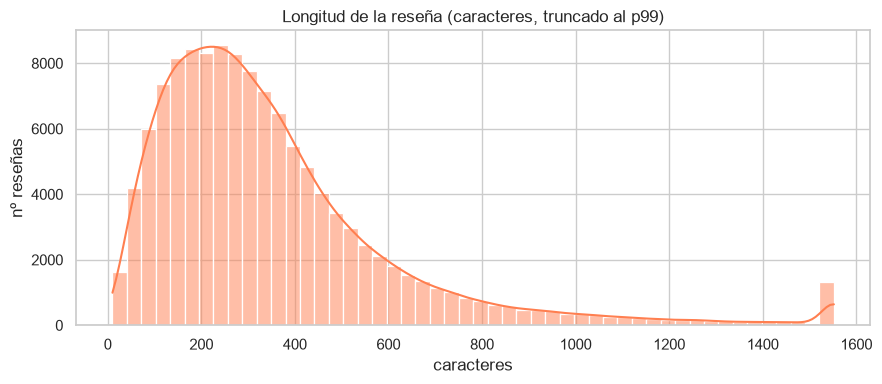

In [6]:
# Distribución de longitudes (truncada al percentil 99 para que se vea bien)
rl = df["review_len"]
plt.figure(figsize=(9, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de la reseña (caracteres, truncado al p99)")
plt.xlabel("caracteres"); plt.ylabel("nº reseñas")
plt.tight_layout(); plt.show()

In [7]:
# Muestra aleatoria para ver con nuestros propios ojos qué caracteres aparecen
for r in df["review"].dropna().sample(8, random_state=RANDOM_STATE):
    print(repr(r[:300]))
    print("-" * 90)

'Your wool is great value, the only thing I can comment on is that the wool was not bagged inside for protection.'
------------------------------------------------------------------------------------------
'I booked this intensive course in July last year… didn’t start my lessons until November because my first instructor was 2 hours late and didn’t pick up the phone and by the time I had got through to national intensive it was too late for me to have my lesson as I had to go to work. My second instru'
------------------------------------------------------------------------------------------
'Superb software at a market leading price. Very intuitive and once all set up for you it saves you hours of accounting time'
------------------------------------------------------------------------------------------
"Never had such flimsy and I'll fitting bra's in my life. Zero support, bad quality elasticiteit, thin materials for the cups, no support what so ever.  I'm an E cup, but these wouldn

In [8]:
# Detectamos patrones que querremos limpiar
sample = df["review"].dropna().astype(str)
print("Con URLs   :", sample.str.contains(r"http\S+|www\.", regex=True).mean().round(3))
print("Con \\n     :", sample.str.contains(r"\n", regex=True).mean().round(3))
print("Con dígitos:", sample.str.contains(r"\d", regex=True).mean().round(3))
print("Con emojis :", sample.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]", regex=True).mean().round(3))

Con URLs   : 0.0
Con \n     : 0.0
Con dígitos: 0.409
Con emojis : 0.027


## 5) Función de limpieza

Creamos dos niveles de limpieza:

- **`clean_soft`**: limpieza ligera (quita URLs, saltos de línea, espacios repetidos) **conservando** mayúsculas, signos y emojis. Es la que pasaremos al **modelo de sentimiento**, porque los transformers entienden mejor el texto natural.
- **`clean_hard`**: limpieza agresiva (minúsculas, sin signos, sin números, sin URLs) para el **topic modeling** con TF-IDF, donde sólo nos interesan las palabras de contenido.

In [9]:
URL_RE   = re.compile(r"http\S+|www\.\S+")
EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u27BF\u2190-\u21FF\u2B00-\u2BFF]")

def clean_soft(text: str) -> str:
    """Limpieza ligera para el modelo de sentimiento."""
    if not isinstance(text, str):
        return ""
    t = URL_RE.sub(" ", text)
    t = t.replace("\\n", " ").replace("\n", " ").replace("\r", " ")
    t = re.sub(r"\s+", " ", t)          # espacios repetidos
    return t.strip()

def clean_hard(text: str) -> str:
    """Limpieza agresiva para TF-IDF / topics."""
    if not isinstance(text, str):
        return ""
    t = text.lower()
    t = URL_RE.sub(" ", t)
    t = EMOJI_RE.sub(" ", t)
    t = re.sub(r"[^a-záéíóúñü\s]", " ", t)  # solo letras
    t = re.sub(r"\s+", " ", t)
    return t.strip()

# Prueba rápida
ejemplo = df["review"].dropna().iloc[0]
print("ORIGINAL :", repr(ejemplo[:200]))
print("SOFT     :", repr(clean_soft(ejemplo)[:200]))
print("HARD     :", repr(clean_hard(ejemplo)[:200]))

ORIGINAL : 'Great quality dog drying robe although had to wait a while for it to come back into stock'
SOFT     : 'Great quality dog drying robe although had to wait a while for it to come back into stock'
HARD     : 'great quality dog drying robe although had to wait a while for it to come back into stock'


In [10]:
# Aplicamos la limpieza a todo el dataset
df["review_soft"] = df["review"].apply(clean_soft)
df["review_hard"] = df["review"].apply(clean_hard)

# Quitamos reseñas vacías o demasiado cortas tras limpiar
before = len(df)
df = df[df["review_soft"].str.len() >= 5].reset_index(drop=True)
print(f"Reseñas: {before} -> {len(df)} (eliminadas {before - len(df)} vacías/cortas)")

Reseñas: 123181 -> 123181 (eliminadas 0 vacías/cortas)


## 6) Filtrado: empresa objetivo y competencia

- **`df_emp`** → reseñas de nuestra empresa (`TARGET`).
- **`df_comp`** → reseñas del resto de empresas del mismo sector (la competencia).

In [11]:
sector = df[df["category"] == CAT].copy()

df_emp  = sector[sector["company"] == TARGET].copy()
df_comp = sector[sector["company"] != TARGET].copy()

print(f"Sector '{CAT}': {len(sector)} reseñas, {sector['company'].nunique()} empresas")
print(f"  - {TARGET}: {len(df_emp)} reseñas")
print(f"  - Competencia: {len(df_comp)} reseñas, {df_comp['company'].nunique()} empresas")

Sector 'Vehicles & Transportation': 5765 reseñas, 60 empresas
  - www.halfords.com: 100 reseñas
  - Competencia: 5665 reseñas, 59 empresas


In [12]:
# Top empresas de la competencia por nº de reseñas
df_comp["company"].value_counts().head(15)

company
www.autowindscreens.co.uk     100
www.nationalexpress.com       100
www.poferries.com             100
www.planetx.co.uk             100
www.protyre.co.uk             100
www.brittany-ferries.co.uk    100
taxis.gatwickairport.com      100
flixbus.co.uk                 100
www.kwik-fit.com              100
www.thetrainline.com          100
www.leisurelakesbikes.com     100
www.national.co.uk            100
www.ferryonline.co.uk         100
www.blackcircles.com          100
www.balfesbikes.co.uk         100
Name: count, dtype: int64

---
## 7) Sentimiento (Deep Learning)

Aplicamos un **modelo de sentimiento pre-entrenado** (transformer) sobre el texto limpio `review_soft`.
**No usamos las estrellas**, porque el dataset está sesgado (todas las empresas tienen la misma distribución de estrellas).

Modelo: `distilbert-base-uncased-finetuned-sst-2-english` — clasificador binario **POSITIVE / NEGATIVE**, ligero y en inglés (las reseñas están en inglés).

> Si tienes GPU se usará automáticamente. En CPU, las ~5.765 reseñas del sector tardan unos minutos. Se cachea el resultado para no repetir el cálculo.

In [13]:
from transformers import pipeline
import torch, os

device = 0 if torch.cuda.is_available() else -1
print("Dispositivo:", "GPU" if device == 0 else "CPU")

sentiment = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=device,
    truncation=True,
    max_length=512,
)

c:\DATOS\GITHUB\EVOLVE\6. Deep Learning\PROYECTO\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: CPU


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 13001.33it/s]


In [14]:
def predict_sentiment(texts, batch_size=32):
    """Devuelve (labels, scores) para una lista de textos."""
    texts = [t if isinstance(t, str) and t.strip() else "neutral" for t in texts]
    labels, scores = [], []
    for out in sentiment(texts, batch_size=batch_size):
        labels.append(out["label"])          # 'POSITIVE' / 'NEGATIVE'
        scores.append(out["score"])          # confianza 0-1
    return labels, scores

In [15]:
# Calculamos el sentimiento de TODO el sector (empresa + competencia) y cacheamos
# Ruta absoluta -> funciona sin importar desde dónde ejecutes el notebook
CACHE = BASE_DIR / "cache_sentiment.csv"

if CACHE.exists():
    sector = pd.read_csv(CACHE)
    print("Sentimiento cargado de cache:", CACHE)
else:
    labels, scores = predict_sentiment(sector["review_soft"].tolist())
    sector["sentiment"]  = labels
    sector["sent_score"] = scores
    # score con signo: +conf si positivo, -conf si negativo (útil para promedios)
    sector["sent_signed"] = sector.apply(
        lambda r: r["sent_score"] if r["sentiment"] == "POSITIVE" else -r["sent_score"], axis=1)
    sector.to_csv(CACHE, index=False)
    print("Sentimiento calculado y guardado en", CACHE)

# Rehacemos los subconjuntos con el sentimiento ya calculado
df_emp  = sector[sector["company"] == TARGET].copy()
df_comp = sector[sector["company"] != TARGET].copy()
sector[["company", "sentiment", "sent_score", "sent_signed"]].head()

Sentimiento cargado de cache: C:\DATOS\GITHUB\EVOLVE\6. Deep Learning\PROYECTO\cache_sentiment.csv


,company,sentiment,sent_score,sent_signed
0,www.autowindscreens.co.uk,NEGATIVE,0.604451,-0.604451
1,www.autowindscreens.co.uk,POSITIVE,0.999796,0.999796
2,www.autowindscreens.co.uk,POSITIVE,0.998529,0.998529
3,www.autowindscreens.co.uk,POSITIVE,0.999541,0.999541
4,www.autowindscreens.co.uk,NEGATIVE,0.633493,-0.633493


### 7.1 Pregunta 1 — ¿Las reseñas son positivas o negativas? ¿Y la competencia?

In [16]:
def resumen_sentimiento(d, nombre):
    pct = d["sentiment"].value_counts(normalize=True).mul(100).round(1)
    print(f"{nombre} (n={len(d)})")
    print(f"  POSITIVE: {pct.get('POSITIVE', 0)}%   NEGATIVE: {pct.get('NEGATIVE', 0)}%")
    return pct.get("POSITIVE", 0)

pos_emp  = resumen_sentimiento(df_emp,  TARGET)
pos_comp = resumen_sentimiento(df_comp, "Competencia (sector)")
print(f"\nDiferencia Halfords vs competencia: {round(pos_emp - pos_comp, 1)} puntos")

www.halfords.com (n=100)
  POSITIVE: 35.0%   NEGATIVE: 65.0%
Competencia (sector) (n=5665)
  POSITIVE: 31.7%   NEGATIVE: 68.3%

Diferencia Halfords vs competencia: 3.3 puntos


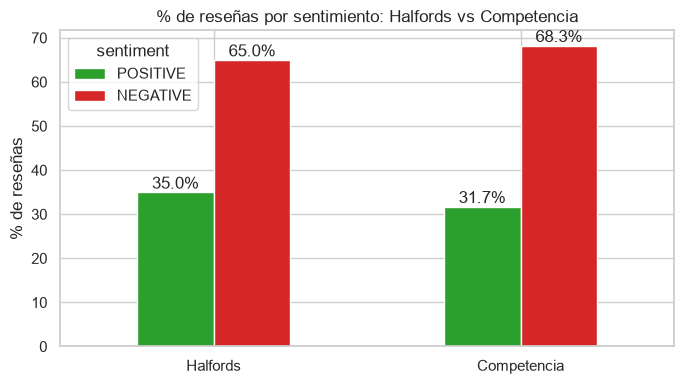

In [17]:
# Gráfico comparativo de sentimiento
comp_df = pd.DataFrame({
    "Halfords":    df_emp["sentiment"].value_counts(normalize=True).mul(100),
    "Competencia": df_comp["sentiment"].value_counts(normalize=True).mul(100),
}).reindex(["POSITIVE", "NEGATIVE"]).T

ax = comp_df.plot(kind="bar", color=["#2ca02c", "#d62728"], figsize=(7, 4))
ax.set_title("% de reseñas por sentimiento: Halfords vs Competencia")
ax.set_ylabel("% de reseñas"); ax.set_xlabel("")
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%")
plt.tight_layout(); plt.show()

In [18]:
# Ranking: % de reseñas positivas por empresa (¿dónde está Halfords?)
rank = (sector.groupby("company")["sentiment"]
        .apply(lambda s: (s == "POSITIVE").mean() * 100)
        .sort_values(ascending=False).round(1))
pos_halfords = rank[TARGET]
puesto = rank.rank(ascending=False)[TARGET]
print(f"Halfords: {pos_halfords}% positivas -> puesto {int(puesto)} de {len(rank)}")
print("\nTop 5 mejores:\n", rank.head(5))
print("\nTop 5 peores:\n", rank.tail(5))

Halfords: 35.0% positivas -> puesto 15 de 60

Top 5 mejores:
 company
albionairportcars.co.uk       71.4
www.sellyourproblemcar.com    64.6
xpressairporttransfer.com     53.0
www.highonbikes.com           50.7
alps2alps.com                 44.6
Name: sentiment, dtype: float64

Top 5 peores:
 company
www.directferries.co.uk    25.0
www.planetx.co.uk          25.0
justpark.com               23.0
www.eurocarparts.com       22.0
www.aferry.com             20.6
Name: sentiment, dtype: float64


---
## 8) Topics (Machine Learning clásico)

Descubrimos **de qué hablan** las reseñas con **TF-IDF + NMF**:

- **TF-IDF** convierte cada reseña en un vector de importancia de palabras.
- **NMF** (factorización de matrices no negativa) agrupa esas palabras en `N_TOPICS` temas.

Ajustamos el modelo sobre **todo el sector** (empresa + competencia) para que ambos compartan **el mismo espacio de topics** y la comparación del Bloque 9 sea directa.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF

# Stopwords en inglés + palabras de dominio poco informativas
extra_stop = ["car", "bike", "bikes", "just", "got", "would", "get",
              "didn", "don", "ve", "really", "halfords"]
stop_words = list(ENGLISH_STOP_WORDS) + extra_stop

vectorizer = TfidfVectorizer(stop_words=stop_words, min_df=5, max_df=0.5,
                             ngram_range=(1, 2))
X = vectorizer.fit_transform(sector["review_hard"].fillna(""))
features = vectorizer.get_feature_names_out()
print("Matriz documento-término:", X.shape)

Matriz documento-término: (5765, 5346)


In [20]:
nmf = NMF(n_components=N_TOPICS, random_state=RANDOM_STATE,
          init="nndsvda", max_iter=400)
W = nmf.fit_transform(X)   # peso de cada topic en cada reseña
H = nmf.components_         # peso de cada palabra en cada topic

def top_words(topic_idx, n=TOP_WORDS):
    return [features[i] for i in H[topic_idx].argsort()[::-1][:n]]

for k in range(N_TOPICS):
    print(f"TOPIC {k}: {', '.join(top_words(k))}")

TOPIC 0: order, days, ordered, received, refund, email, item, day, sent, told, stock, arrived
TOPIC 1: delivery, great, product, fast, quick, fast delivery, day, quick delivery, delivered, day delivery, item, quality
TOPIC 2: tyres, tyre, fitted, fitting, new, tyres fitted, fitter, garage, appointment, new tyres, wheel, time
TOPIC 3: service, customer, customer service, great, great service, excellent, poor, great customer, services, response, excellent service, company
TOPIC 4: booking, easy, book, ferry, use, website, parking, space, ticket, app, easy use, booked
TOPIC 5: driver, journey, airport, bus, time, late, comfortable, coach, minutes, taxi, train, flight
TOPIC 6: staff, friendly, work, helpful, repair, recommend, job, mot, time, great, efficient, did
TOPIC 7: good, price, good service, good price, experience, quality, service good, bit, good experience, service, value, communication


In [21]:
# Etiquetas legibles para cada topic (revísalas/edítalas tras ver las palabras de arriba)
TOPIC_LABELS = {
    0: "Pedidos online y reembolsos",
    1: "Entrega rápida y producto",
    2: "Neumáticos y montaje",
    3: "Atención al cliente",
    4: "Reservas y web/app",
    5: "Transporte y viajes",
    6: "Personal en tienda y taller (MOT/reparación)",
    7: "Precio y relación calidad-precio",
}

# Asignamos a cada reseña su topic dominante
sector["topic"]       = W.argmax(axis=1)
sector["topic_label"] = sector["topic"].map(TOPIC_LABELS)

# Rehacemos los subconjuntos con topic incluido
df_emp  = sector[sector["company"] == TARGET].copy()
df_comp = sector[sector["company"] != TARGET].copy()
sector[["company", "topic", "topic_label"]].head()

,company,topic,topic_label
0,www.autowindscreens.co.uk,6,Personal en tienda y taller (MOT/reparación)
1,www.autowindscreens.co.uk,3,Atención al cliente
2,www.autowindscreens.co.uk,6,Personal en tienda y taller (MOT/reparación)
3,www.autowindscreens.co.uk,6,Personal en tienda y taller (MOT/reparación)
4,www.autowindscreens.co.uk,4,Reservas y web/app


### 8.1 Pregunta 2 — ¿Qué temas tratan las reseñas? ¿Y la competencia?

In [22]:
# Distribución de topics: Halfords vs Competencia
dist = pd.DataFrame({
    "Halfords":    df_emp["topic_label"].value_counts(normalize=True).mul(100),
    "Competencia": df_comp["topic_label"].value_counts(normalize=True).mul(100),
}).fillna(0).round(1)
dist = dist.sort_values("Halfords", ascending=False)
dist

,Halfords,Competencia
topic_label,,
Personal en tienda y taller (MOT/reparación),45.0,20.3
Atención al cliente,19.0,9.2
Pedidos online y reembolsos,13.0,13.5
Neumáticos y montaje,8.0,9.5
Reservas y web/app,8.0,15.8
Entrega rápida y producto,3.0,10.1
Precio y relación calidad-precio,3.0,10.0
Transporte y viajes,1.0,11.7


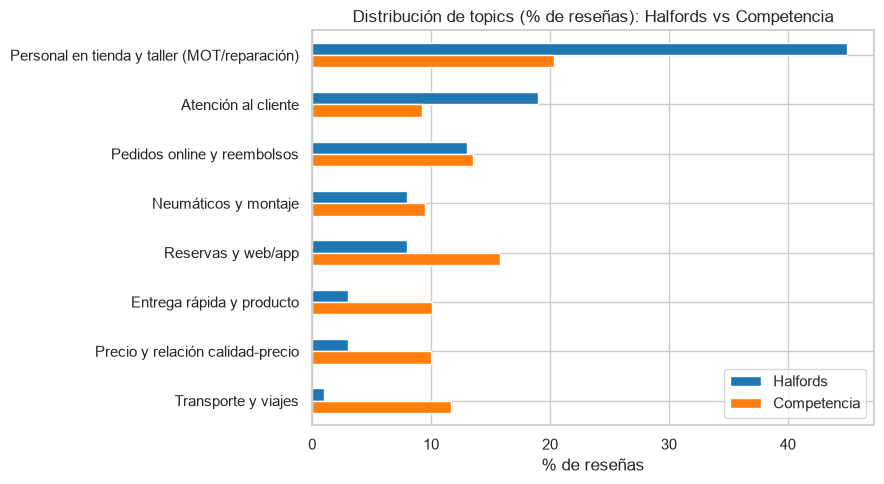

In [23]:
ax = dist.plot(kind="barh", figsize=(9, 5), color=["#1f77b4", "#ff7f0e"])
ax.set_title("Distribución de topics (% de reseñas): Halfords vs Competencia")
ax.set_xlabel("% de reseñas"); ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout(); plt.show()

**Lectura:** las barras muestran el peso de cada tema. Los temas donde Halfords pesa **mucho más** que la competencia son los que más definen su experiencia de cliente (foco del análisis de mejora).

---
## 9) Sentimiento × Topic y comparación con la competencia

Cruzamos los dos análisis anteriores: para **cada topic** medimos qué porcentaje de reseñas es positivo, en Halfords y en la competencia. Así respondemos:

- **Pregunta 3:** ¿el sentimiento de cada tema es positivo o negativo? ¿En qué somos mejores/peores que la competencia?
- **Pregunta 4:** ¿dónde están las áreas de mejora?

> Usamos `MIN_N` para marcar los topics con pocas reseñas en Halfords (poco fiables).

In [24]:
MIN_N = 8  # nº mínimo de reseñas para considerar un topic fiable en Halfords

def pct_pos_por_topic(d):
    return d.groupby("topic_label")["sentiment"].apply(lambda s: (s == "POSITIVE").mean() * 100)

tabla = pd.DataFrame({
    "% pos Halfords":     pct_pos_por_topic(df_emp),
    "% pos Competencia":  pct_pos_por_topic(df_comp),
    "n Halfords":         df_emp["topic_label"].value_counts(),
    "% vol Halfords":     df_emp["topic_label"].value_counts(normalize=True) * 100,
})
tabla["dif (H - C)"] = tabla["% pos Halfords"] - tabla["% pos Competencia"]
tabla["fiable"]      = tabla["n Halfords"] >= MIN_N
tabla = tabla.round(1).sort_values("% vol Halfords", ascending=False)
tabla

,% pos Halfords,% pos Competencia,n Halfords,% vol Halfords,dif (H - C),fiable
topic_label,,,,,,
Personal en tienda y taller (MOT/reparación),46.7,41.9,45,45.0,4.7,True
Atención al cliente,36.8,36.9,19,19.0,-0.1,True
Pedidos online y reembolsos,7.7,10.5,13,13.0,-2.8,True
Neumáticos y montaje,12.5,18.9,8,8.0,-6.4,True
Reservas y web/app,12.5,25.4,8,8.0,-12.9,True
Entrega rápida y producto,66.7,38.2,3,3.0,28.5,False
Precio y relación calidad-precio,33.3,49.4,3,3.0,-16.0,False
Transporte y viajes,100.0,32.9,1,1.0,67.1,False


### 9.1 % de reseñas positivas por topic: Halfords vs Competencia

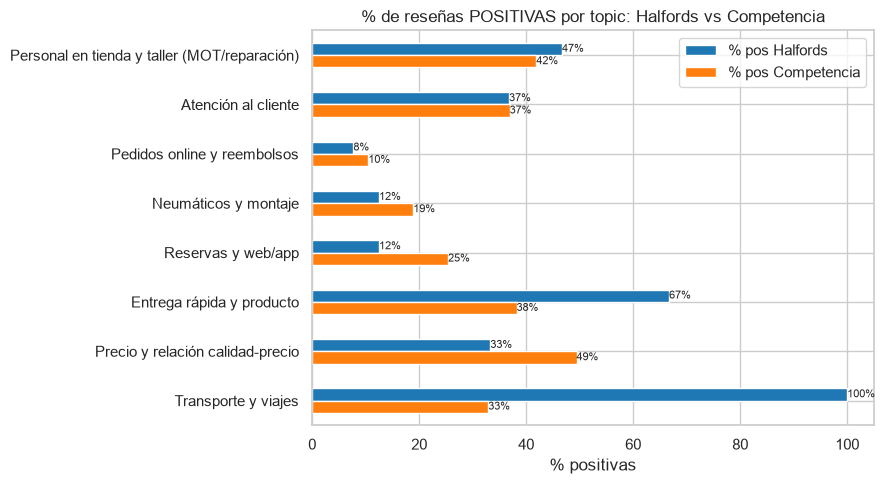

In [25]:
plot_df = tabla[["% pos Halfords", "% pos Competencia"]]
ax = plot_df.plot(kind="barh", figsize=(9, 5), color=["#1f77b4", "#ff7f0e"])
ax.set_title("% de reseñas POSITIVAS por topic: Halfords vs Competencia")
ax.set_xlabel("% positivas"); ax.set_ylabel("")
ax.invert_yaxis()
for c in ax.containers:
    ax.bar_label(c, fmt="%.0f%%", fontsize=8)
plt.tight_layout(); plt.show()

### 9.2 ¿En qué somos mejores / peores? (diferencia Halfords − Competencia)

Barras a la **derecha (verde)** = Halfords mejor que la competencia. A la **izquierda (rojo)** = peor.
Los topics poco fiables (n < MIN_N) se muestran con borde gris.

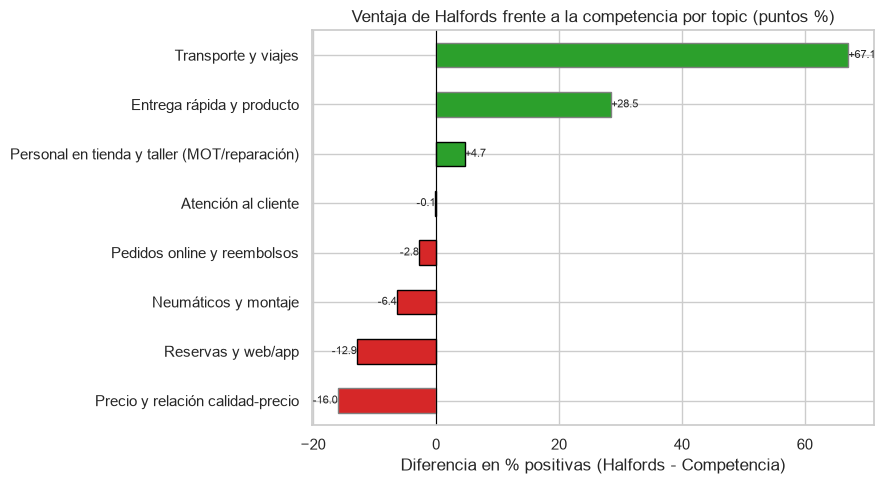

In [26]:
dif = tabla.sort_values("dif (H - C)")
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in dif["dif (H - C)"]]
ax = dif["dif (H - C)"].plot(kind="barh", figsize=(9, 5), color=colors,
                             edgecolor=["black" if f else "gray" for f in dif["fiable"]])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Ventaja de Halfords frente a la competencia por topic (puntos %)")
ax.set_xlabel("Diferencia en % positivas (Halfords - Competencia)"); ax.set_ylabel("")
for c in ax.containers:
    ax.bar_label(c, fmt="%+.1f", fontsize=8)
plt.tight_layout(); plt.show()

### 9.3 Pregunta 4 — Áreas de mejora (priorizadas)

Priorizamos por **impacto**: topics con **mucho volumen** en Halfords, **bajo % positivo** y **peores que la competencia**. Filtramos los poco fiables (n < MIN_N).

In [27]:
fiables = tabla[tabla["fiable"]].copy()

# Debilidades: peor que la competencia (dif < 0), ordenadas por volumen
debilidades = (fiables[fiables["dif (H - C)"] < 0]
               .sort_values("% vol Halfords", ascending=False))
# Fortalezas: mejor que la competencia (dif >= 0)
fortalezas  = (fiables[fiables["dif (H - C)"] >= 0]
               .sort_values("% vol Halfords", ascending=False))

print("=== ÁREAS DE MEJORA (peores que la competencia, por volumen) ===")
for t, r in debilidades.iterrows():
    print(f"  - {t}: {r['% pos Halfords']}% pos | {r['% vol Halfords']}% del volumen | {r['dif (H - C)']:+} vs competencia")

print("\n=== FORTALEZAS (mejores que la competencia) ===")
for t, r in fortalezas.iterrows():
    print(f"  - {t}: {r['% pos Halfords']}% pos | {r['% vol Halfords']}% del volumen | {r['dif (H - C)']:+} vs competencia")

=== ÁREAS DE MEJORA (peores que la competencia, por volumen) ===
  - Atención al cliente: 36.8% pos | 19.0% del volumen | -0.1 vs competencia
  - Pedidos online y reembolsos: 7.7% pos | 13.0% del volumen | -2.8 vs competencia
  - Neumáticos y montaje: 12.5% pos | 8.0% del volumen | -6.4 vs competencia
  - Reservas y web/app: 12.5% pos | 8.0% del volumen | -12.9 vs competencia

=== FORTALEZAS (mejores que la competencia) ===
  - Personal en tienda y taller (MOT/reparación): 46.7% pos | 45.0% del volumen | +4.7 vs competencia


### 9.4 Evidencia cualitativa: ejemplos de reseñas negativas del área prioritaria

Leemos reseñas negativas reales del topic más problemático para entender **qué** falla concretamente.

In [28]:
# Topic prioritario = la mayor debilidad por volumen
if len(debilidades):
    topic_foco = debilidades.index[0]
    ejemplos = df_emp[(df_emp["topic_label"] == topic_foco) &
                      (df_emp["sentiment"] == "NEGATIVE")].sort_values("sent_score", ascending=False)
    print(f"TOPIC FOCO: {topic_foco}  (mostrando {min(5, len(ejemplos))} reseñas negativas)\n")
    for txt in ejemplos["review"].head(5):
        print("-", str(txt)[:280], "\n")

TOPIC FOCO: Atención al cliente  (mostrando 5 reseñas negativas)

- I booked and paid for an Mot and major service but Halfords can't seem to provide a record of the service report. I've been attempting to obtain this for almost a month. Each time I email, I get a generic response and told I'll get a response within 48 hours. Each time, no respon 

- Whilst the actual mobile tyre service when it happened was ok, Halfords admin is pretty chaotic. They do not want to talk to you but direct you to a chat which never works and re-directs to a phone number which then re-directs you unless you hold to the chat. Does nobody at Halfo 

- Have updated my review to include my customer number 2226171542. I'm not sure what this will help as my husband has attached the mud guards and lights. Bought a bike for my son for Christmas and some extra bits,mud guards and lights paid the charge for the bike to be put together 

- Bought 2 winter tyres from Halfords last night and used their payment assist 

---
## 10) Visualizaciones

Resumimos visualmente los hallazgos: nubes de palabras de las reseñas positivas y negativas de Halfords, y un mapa de calor de sentimiento por topic.

In [29]:
from wordcloud import WordCloud

# Stopwords para las nubes (reutilizamos las de los topics)
wc_stop = set(stop_words)

def make_wordcloud(textos, titulo, color):
    texto = " ".join(textos.fillna("").astype(str))
    wc = WordCloud(width=800, height=400, background_color="white",
                   stopwords=wc_stop, colormap=color, max_words=80).generate(texto)
    plt.figure(figsize=(9, 4.5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(titulo)
    plt.tight_layout(); plt.show()

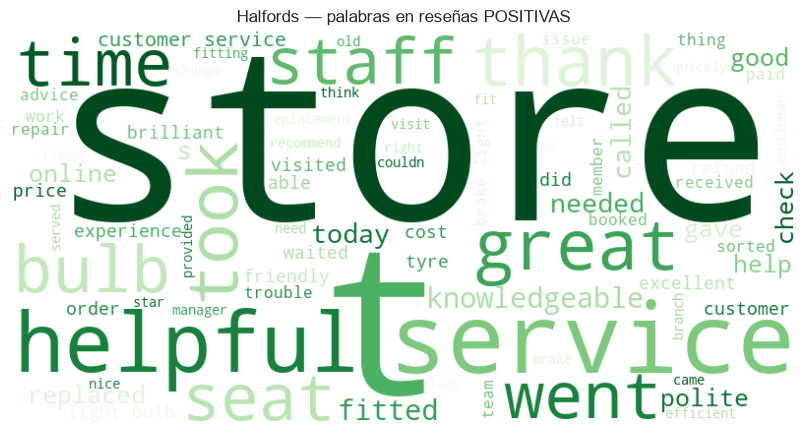

In [30]:
# Nube de palabras de reseñas POSITIVAS de Halfords
make_wordcloud(df_emp[df_emp["sentiment"] == "POSITIVE"]["review_hard"],
               "Halfords — palabras en reseñas POSITIVAS", "Greens")

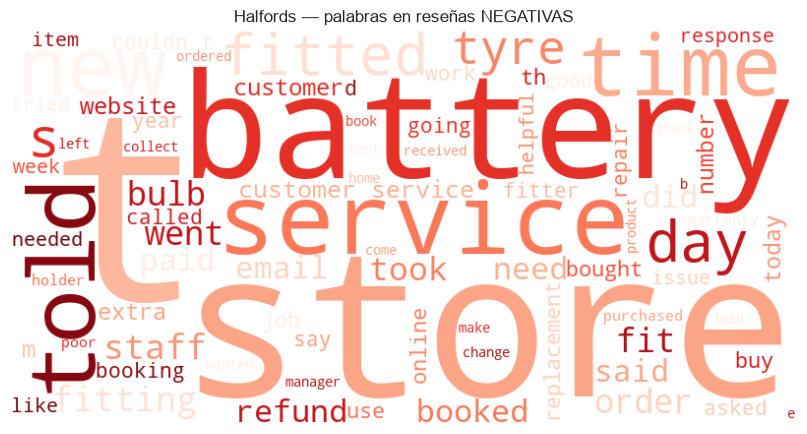

In [31]:
# Nube de palabras de reseñas NEGATIVAS de Halfords (puntos de dolor)
make_wordcloud(df_emp[df_emp["sentiment"] == "NEGATIVE"]["review_hard"],
               "Halfords — palabras en reseñas NEGATIVAS", "Reds")

### 10.1 Mapa de calor: % positivas por topic (Halfords vs Competencia)

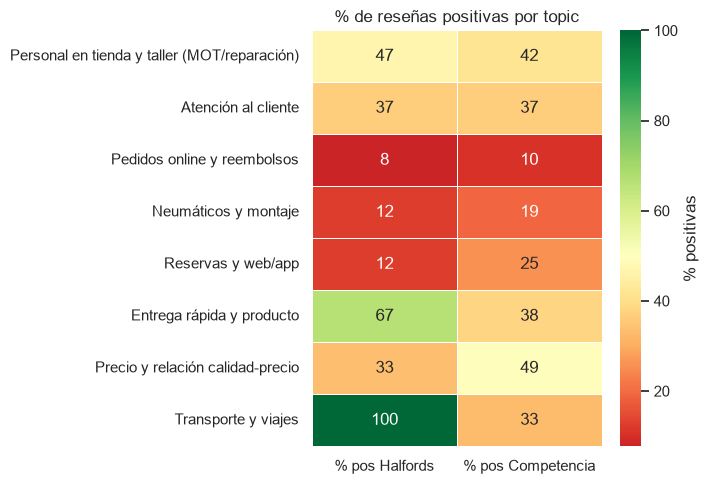

In [32]:
heat = tabla[["% pos Halfords", "% pos Competencia"]].copy()
plt.figure(figsize=(7, 5))
sns.heatmap(heat, annot=True, fmt=".0f", cmap="RdYlGn", center=50,
            cbar_kws={"label": "% positivas"}, linewidths=0.5)
plt.title("% de reseñas positivas por topic")
plt.ylabel(""); plt.xlabel("")
plt.tight_layout(); plt.show()

---
## 11) Conclusiones

**Objetivo:** analizar las reseñas de Trustpilot de **Halfords** (sector *Vehicles & Transportation*) con técnicas de NLP para detectar oportunidades de mejora, comparándola con sus 59 competidores del sector.

**Hipótesis de partida:** dado que la muestra de estrellas está balanceada (no fiable), un modelo de sentimiento NLP daría una imagen más realista de la experiencia de cliente.

**1. Sentimiento global.** Predominan las reseñas **negativas**: Halfords ~65% negativas / ~35% positivas. Aun así, está **mejor que la media del sector** (~68% negativas) y ocupa el **puesto 15 de 60** en % de reseñas positivas. El sector entero es muy crítico.

**2. Temas (topics).** Las reseñas de Halfords se concentran en **Personal en tienda y taller (MOT/reparación)** (45%) y **Atención al cliente** (19%), seguidas de **Pedidos online y reembolsos** (13%). La competencia está mucho más repartida (reservas, transporte, entregas), reflejo de su modelo de tienda física + taller.

**3. Sentimiento por tema y vs competencia.**
- **Fortaleza:** *Personal en tienda y taller* — el tema más voluminoso y donde **superamos a la competencia** (+4.7 pts). El factor humano y el servicio de taller son el principal activo.
- **Debilidades:** *Reservas y web/app* (−12.9 pts vs competencia), *Neumáticos y montaje* (−6.4) y *Pedidos online y reembolsos* (solo 7.7% positivas). El punto débil es **lo digital y la postventa**.

**4. Áreas de mejora (priorizadas).**
1. **Postventa y pedidos online:** confirmaciones de pago/compra que no llegan, informes de MOT no entregados, reembolsos lentos. Es el área con peor sentimiento y alto volumen.
2. **Experiencia web/app y reservas:** la mayor brecha frente a la competencia; simplificar el flujo de reserva y el chat de soporte.
3. **Click & collect y gestión de montaje:** reducir esperas y errores en la recogida.

**Recomendación:** mantener y potenciar la fortaleza del taller/personal (comunicarla en marketing) mientras se ataca de raíz la fricción digital y de postventa, que es donde Halfords pierde frente a sus competidores.

> *Nota metodológica:* el sentimiento se obtuvo con el transformer `distilbert-sst-2` (binario), no con las estrellas. Los topics con pocas reseñas en Halfords (n < 8) se excluyeron del análisis de prioridades por baja fiabilidad.